In [1]:
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import math
import torch
import gpytorch
import tqdm.notebook as tqdm

torch.set_default_dtype(torch.double)

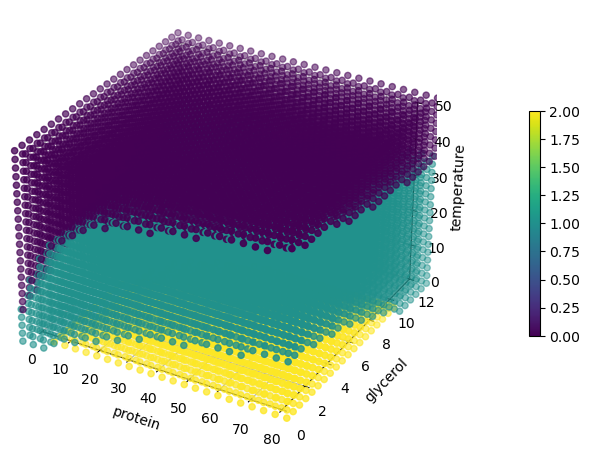

In [74]:
boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')

fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

ax = ax
mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=boundary_dataset.labels.values
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [75]:
X = boundary_dataset["composition"].values
y = boundary_dataset.labels.values

In [76]:

Xt = torch.from_numpy(X.T)
yt = torch.from_numpy(y).long().squeeze()

In [77]:
train_n = int(math.floor(0.8 * len(Xt)))
train_x = Xt[:train_n, :].contiguous()
train_y = yt[:train_n].contiguous()

test_x = Xt[train_n:, :].contiguous()
test_y = yt[train_n:].contiguous()

In [78]:
from gpytorch.means import ConstantMean
from gpytorch.kernels import ScaleKernel, RBFKernel, InducingPointKernel
from gpytorch.distributions import MultivariateNormal

class GPRegressionModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, num_classes):
        super(GPRegressionModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()
        self.base_covar_module = ScaleKernel(
            RBFKernel(batch_shape=torch.Size((num_classes,))),
            batch_shape=torch.Size((num_classes,)),
        )
        self.covar_module = InducingPointKernel(self.base_covar_module, 
                                                inducing_points=train_x[:500, :].clone(), 
                                                likelihood=likelihood
                                            )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

In [79]:
from gpytorch.likelihoods import DirichletClassificationLikelihood

likelihood = DirichletClassificationLikelihood(train_y, learn_additional_noise=True)
model = GPRegressionModel(train_x, train_y, likelihood, num_classes=3)

In [80]:
training_iterations = 100

# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

def train():
    iterator = tqdm.tqdm(range(training_iterations), desc="GP-Train")

    for i in iterator:
        # Zero backprop gradients
        optimizer.zero_grad()
        # Get output from model
        output = model(train_x)
        # Calc loss and backprop derivatives
        loss = -mll(output, train_y).sum()
        loss.backward()
        iterator.set_postfix(loss=loss.item())
        optimizer.step()
        torch.cuda.empty_cache()

%time train()

GP-Train:   0%|          | 0/100 [00:00<?, ?it/s]

RuntimeError: Shape mismatch: objects cannot be broadcast to a single shape

In [81]:
model.eval()
likelihood.eval()

with gpytorch.settings.fast_pred_var(), torch.no_grad():
    test_dist = model(Xt)
    pred_means = test_dist.loc

# Monte Carlo sampling for probability estimation
pred_samples = test_dist.sample(torch.Size((256,))).exp()
probabilities = (pred_samples / pred_samples.sum(-2, keepdim=True)).mean(0)
entropy = torch.special.entr(probabilities).sum(0)

RuntimeError: Shape mismatch: objects cannot be broadcast to a single shape

In [82]:
train_y

tensor([0, 0, 0,  ..., 1, 1, 1])